In [1]:
import ast
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

label = 'pident_90'
os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

def process_replicon_data(fraction_data):
    typ_chr = fraction_data[fraction_data[f'category-{label}'] == 'typical chromosome']
    min_size = min(typ_chr['size'])
    tra_rep = fraction_data[fraction_data[f'category-{label}'] == 'intermediate replicon']
    if tra_rep.empty:
        return min_size * 0.5
    else:
        tra_max = max(tra_rep['size'])
        return (min_size + tra_max)/2

top_5_genus = keep_genus[:5]
single_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

In [3]:
def split_axes_with_marginal_density(parent_ax, top_h_ratio=0.15, right_w_ratio=0.15, w_gap=0.02, h_gap=0.02):
    fig = parent_ax.figure
    p_left, p_bottom, p_w, p_h = parent_ax.get_position().bounds

    main_w = p_w * (1 - (right_w_ratio + w_gap))
    main_h = p_h * (1 - (top_h_ratio + h_gap))
    main_x0 = p_left
    main_y0 = p_bottom

    top_x0 = main_x0
    top_y0 = main_y0 + main_h + h_gap * p_h
    top_w = main_w
    top_h = p_h * top_h_ratio

    right_x0 = main_x0 + main_w + w_gap * p_w
    right_y0 = main_y0
    right_w = p_w * right_w_ratio
    right_h = main_h

    ax_main = fig.add_axes([main_x0, main_y0, main_w, main_h])
    ax_top_x = fig.add_axes([top_x0, top_y0, top_w, top_h])
    ax_right_y = fig.add_axes([right_x0, right_y0, right_w, right_h])

    parent_ax.set_axis_off()
    return ax_main, ax_top_x, ax_right_y

def plot_x_density(ax_dens, x_data, color):
    log_x = np.log10(x_data)
    kde = gaussian_kde(log_x, bw_method=0.1)
    log_x_min = np.log10(100)
    log_x_max = np.log10(5e7)
    log_x_range = np.linspace(log_x_min, log_x_max, 500)
    dens_vals = kde(log_x_range)
    x_real = 10 ** log_x_range
    ax_dens.plot(log_x_range, dens_vals, color=color, lw=0.5)
    ax_dens.fill_between(log_x_range, dens_vals, alpha=0.3, color=color)
    ax_dens.set_xlim(log_x_min, log_x_max)
    ax_dens.set_ylim(bottom=0)
    ax_dens.set_xticklabels([])

def plot_y_density(ax_dens, y_data, color):
    kde = gaussian_kde(y_data, bw_method=0.1)
    y_range = np.linspace(0, 1, 500)
    dens = kde(y_range)
    ax_dens.plot(dens, y_range, color=color, lw=0.5)
    ax_dens.fill_betweenx(y_range, dens, alpha=0.3, color=color)
    ax_dens.set_ylim(-0.05, 1.05)
    ax_dens.set_xlim(left=0)
    ax_dens.set_yticklabels([])

def draw_scatter_plot(genus_name, parent_ax, detail=True, gap=0.02, color=None):
    ax_main, ax_top_x, ax_right_y = split_axes_with_marginal_density(parent_ax, w_gap=gap, h_gap=gap)
    
    folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    df = pd.read_csv(f'{folder}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
    size_split = process_replicon_data(df)
    
    rect1 = Rectangle((x_min, threshold), x_max-x_min, y_max-threshold, facecolor='#cce7ff', alpha=0.8, zorder=1)
    ax_main.add_patch(rect1)
    rect2 = Rectangle((x_min, y_min), size_split-x_min, threshold-y_min, facecolor='#e6f7e6', alpha=0.8, zorder=1)
    ax_main.add_patch(rect2)
    rect3 = Rectangle((size_split, y_min), x_max-size_split, threshold-y_min, facecolor='#f9e4c8', alpha=0.8, zorder=1)
    ax_main.add_patch(rect3)
    ax_main.axhline(y=threshold, color='gray', linestyle='--', linewidth=0.8)

    if detail:
        org_count = df['organism'].value_counts()
        total_species = len(org_count)
        if total_species > 5:
            top_n = list(org_count.index)[0:4]
        else:
            top_n = list(org_count.index)
        
        for i, index in enumerate(top_n):
            temp_data = df[df['organism'] == index]
            x = temp_data['size']
            y = temp_data['average plasmid fraction-pident_90']
            c = plt.cm.tab10(i)
            ax_main.scatter(x, y, marker='o', s=3, alpha=1, edgecolors='none',
                       label=index.replace(genus_name, f'{genus_name[0]}.'), zorder=3, color=c)
        
        if total_species > 5:
            temp_data = df[~(df['organism'].isin(top_n))]
            x_oth = temp_data['size']
            y_oth = temp_data['average plasmid fraction-pident_90']
            ax_main.scatter(x_oth, y_oth, marker='o', s=3, color='gray', alpha=1, edgecolors='none', label='Others', zorder=1)
        
        legend = ax_main.legend(loc='upper right', handletextpad=0, prop=italic_font)
        for text in legend.get_texts():
            if text.get_text() == 'Others':
                text.set_fontproperties(normal_font)
            else:
                text.set_fontproperties(italic_font)
        
        text_color1 = '#0056b0'
        text_color2 = '#006622'
        text_color3 = '#d86f16'
        ax_main.text(x=4.5e7, y=threshold + 0.03, s='Typical plasmid', color=text_color1, fontproperties=font_prop, fontsize=7, va='center', ha='right', zorder=5)
        ax_main.text(x=1.2*10**2, y=threshold - 0.03, s='Intermediate replicon', color=text_color2, fontproperties=font_prop, fontsize=7, va='center', ha='left', zorder=5)
        ax_main.text(x=4.5e7, y=threshold - 0.03, s='Typical chromosome', color=text_color3, fontproperties=font_prop, fontsize=7, va='center', ha='right', zorder=5)
        ax_main.text(1e2, threshold, '0.3', va='center', ha='right', fontsize=7, color='gray')
    else:
        x = df['size'].values
        y = df['average plasmid fraction-pident_90'].values
        if color:
            ax_main.scatter(x, y, marker='o', s=3, alpha=1, edgecolors='none', zorder=1, color=color)
        else:
            ax_main.scatter(x, y, marker='o', s=3, alpha=1, edgecolors='none', zorder=1)
        ax_top_x.tick_params(axis='x', length=1.5)
        ax_right_y.tick_params(axis='y', length=1.5)

    plot_x_density(ax_top_x, np.array(df['size']), color="#666666")
    plot_y_density(ax_right_y, np.array(df['average plasmid fraction-pident_90']), color="#666666")
    
    ax_main.set_xlabel('Size / bp')
    ax_main.set_ylabel('Plasmidness')
    ax_main.set_xscale('log')
    parent_ax.set_title(genus_name, fontproperties=title_font, pad=1)
    ax_main.set_xlim(x_min, x_max)
    ax_main.set_ylim(y_min, y_max)
    ax_main.tick_params(axis='both')

    return ax_main, ax_top_x, ax_right_y

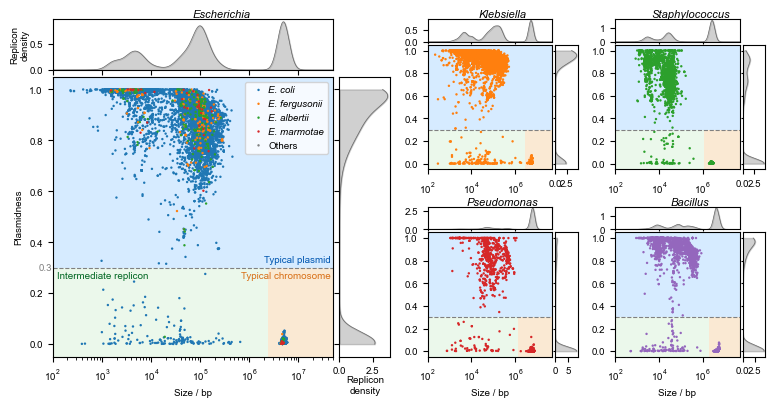

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from scipy.stats import gaussian_kde

threshold = 0.3
x_min, x_max = 100, 5e7
y_min, y_max = -0.05, 1.05

fig = plt.figure(figsize=(7.5, 7.5))
ax1 = fig.add_axes([0.05, 0.55, 0.45, 0.45])
ax2 = fig.add_axes([0.55, 0.8, 0.20, 0.20])
ax3 = fig.add_axes([0.8, 0.8, 0.20, 0.20])
ax4 = fig.add_axes([0.55, 0.55, 0.20, 0.20])
ax5 = fig.add_axes([0.8, 0.55, 0.20, 0.20])

ax_main1, ax_top_x1, ax_right_y1 = draw_scatter_plot(top_5_genus[0], ax1, detail=True)
ax_top_x1.set_ylabel('Replicon\ndensity', labelpad=0)
ax_right_y1.set_xlabel('Replicon\ndensity', labelpad=0)
ax_main2, ax_top_x2, ax_right_y2 = draw_scatter_plot(top_5_genus[1], ax2, detail=False, color=single_colors[1])
ax_main2.set_ylabel('')
ax_main2.set_xlabel('')
ax_main3, ax_top_x3, ax_right_y3 = draw_scatter_plot(top_5_genus[2], ax3, detail=False, color=single_colors[2])
ax_main3.set_ylabel('')
ax_main3.set_xlabel('')
ax_main4, ax_top_x4, ax_right_y4 = draw_scatter_plot(top_5_genus[3], ax4, detail=False, color=single_colors[3])
ax_main4.set_ylabel('')
ax_main5, ax_top_x5, ax_right_y5 = draw_scatter_plot(top_5_genus[4], ax5, detail=False, color=single_colors[4])
ax_main5.set_ylabel('')

figure_fold = '/active-data/analysis_results/chr_pla/genus/figures/scatter_plot'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig("Top5_genus_2x4_layout.svg", bbox_inches="tight", transparent=True)
plt.savefig("Top5_genus_2x4_layout.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()